# Overall Telescope Alterr Standard Deviation (2019-2026)

This notebook analyzes the overall standard deviation of telescope altitude tracking errors from 2019 to the present, aggregating data from all instruments to show long-term trends in mechanical performance.

## 1. Import Required Libraries

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Configure matplotlib for interactive display
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 1.5

## 2. Load Telescope Data from JSON Files

In [2]:
# Path to the results directory containing JSON files
results_dir = Path('./results')

# Load all JSON files
all_data = []
json_files = sorted(results_dir.glob('*.json'))

print(f"Loading {len(json_files)} JSON files from {results_dir}...")

for json_file in json_files:
    try:
        with open(json_file, 'r') as f:
            data = json.load(f)
        
        # Extract metadata and stddev statistics for all directions
        metadata = data.get('metadata', {})
        stats_by_direction = data.get('statistics_by_direction', {})
        
        # Parse timestamps
        start_time_str = metadata.get('run_start_datetime', '')
        end_time_str = metadata.get('run_end_datetime', '')
        
        if start_time_str and end_time_str:
            try:
                start_time = pd.to_datetime(start_time_str)
                end_time = pd.to_datetime(end_time_str)
                
                # Use midpoint of the observation as the timestamp
                timestamp = start_time + (end_time - start_time) / 2
                
                # Extract data for each direction
                for direction in ['BOTH', 'UP', 'DOWN']:
                    stats = stats_by_direction.get(direction, {})
                    stddev_data = stats.get('standard_deviation', {})
                    mean_stddev_arcsec = stddev_data.get('mean_stddev_arcsec', None)
                    
                    if mean_stddev_arcsec is not None:
                        all_data.append({
                            'timestamp': timestamp,
                            'instrument': metadata.get('instrument', 'unknown'),
                            'direction': direction,
                            'mean_stddev_arcsec': mean_stddev_arcsec,
                            'std_stddev_arcsec': stddev_data.get('std_stddev_arcsec', None),
                            'data_points': stddev_data.get('data_points', 0),
                        })
            except Exception as e:
                print(f"  Warning: Could not parse timestamps in {json_file.name}: {e}")
                continue
    except Exception as e:
        print(f"  Error loading {json_file.name}: {e}")
        continue

# Create DataFrame
df = pd.DataFrame(all_data)
print(f"Successfully loaded {len(df)} records from {len(json_files)} files")

Loading 274 JSON files from results...
Successfully loaded 822 records from 274 files


In [3]:
# Display data summary
if len(df) > 0:
    df = df.sort_values('timestamp')
    print(f"Data range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"Number of unique instruments: {df['instrument'].nunique()}")
    print(f"Instruments: {sorted(df['instrument'].unique())}")
    print(f"\nData summary:")
    print(df.describe())
else:
    print("No data loaded!")

Data range: 2019-01-07 02:26:15.500000 to 2026-02-12 13:19:48.514000
Number of unique instruments: 6
Instruments: ['binospec', 'blue', 'hecto', 'mmirs', 'red', 'spol']

Data summary:
                        timestamp  mean_stddev_arcsec  std_stddev_arcsec  \
count                         822          819.000000         819.000000   
mean   2022-08-14 19:45:56.947903            0.070174           0.063538   
min    2019-01-07 02:26:15.500000            0.015313           0.007091   
25%    2020-10-29 11:55:33.987000            0.052496           0.046882   
50%    2022-08-31 12:32:29.944250            0.067478           0.063604   
75%    2024-09-16 22:13:35.672500            0.083412           0.077996   
max    2026-02-12 13:19:48.514000            0.345207           0.177350   
std                           NaN            0.027386           0.024135   

        data_points  
count  8.220000e+02  
mean   1.949153e+06  
min    1.000000e+00  
25%    5.093985e+05  
50%    1.324826e+06  


## 3. Filter Data by Date Range (2019 to Present)

In [4]:
# Filter data to 2019 to present
start_date = pd.to_datetime('2019-01-01')
end_date = pd.to_datetime('2026-12-31')

df_filtered = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)].copy()
print(f"Filtered data range: {df_filtered['timestamp'].min()} to {df_filtered['timestamp'].max()}")
print(f"Records in filtered dataset: {len(df_filtered)}")
print(f"Columns: {df_filtered.columns.tolist()}")

Filtered data range: 2019-01-07 02:26:15.500000 to 2026-02-12 13:19:48.514000
Records in filtered dataset: 822
Columns: ['timestamp', 'instrument', 'direction', 'mean_stddev_arcsec', 'std_stddev_arcsec', 'data_points']


## 4. Calculate Rolling Averages and Monthly Aggregates

In [5]:
# Set timestamp as index for time series analysis
df_ts = df_filtered.set_index('timestamp').sort_index()

# Calculate monthly average stddev (aggregate across all instruments)
monthly_avg = df_ts['mean_stddev_arcsec'].resample('MS').mean()
monthly_std = df_ts['mean_stddev_arcsec'].resample('MS').std()
monthly_count = df_ts['mean_stddev_arcsec'].resample('MS').count()

# Create a DataFrame for monthly statistics
monthly_stats = pd.DataFrame({
    'mean_stddev': monthly_avg,
    'std_stddev': monthly_std,
    'count': monthly_count
})

print("Monthly Average Standard Deviation (arcsec):")
print(monthly_stats)

# Calculate rolling average (90-day window)
rolling_avg_90d = df_ts['mean_stddev_arcsec'].rolling(window='90D').mean()

# Overall statistics
print(f"\n\nOverall Statistics (2019-2026):")
print(f"Mean stddev: {df_filtered['mean_stddev_arcsec'].mean():.4f} arcsec")
print(f"Median stddev: {df_filtered['mean_stddev_arcsec'].median():.4f} arcsec")
print(f"Std dev of stddev: {df_filtered['mean_stddev_arcsec'].std():.4f} arcsec")
print(f"Min stddev: {df_filtered['mean_stddev_arcsec'].min():.4f} arcsec")
print(f"Max stddev: {df_filtered['mean_stddev_arcsec'].max():.4f} arcsec")

Monthly Average Standard Deviation (arcsec):
            mean_stddev  std_stddev  count
timestamp                                 
2019-01-01     0.052340    0.013261     17
2019-02-01     0.068546    0.029327     15
2019-03-01     0.052235    0.009748      9
2019-04-01     0.054646    0.009318     15
2019-05-01     0.060363    0.015896      9
...                 ...         ...    ...
2025-10-01     0.056128    0.022957      9
2025-11-01     0.081313    0.021929      9
2025-12-01     0.062378    0.012630     15
2026-01-01     0.050447    0.015757     15
2026-02-01     0.081845    0.050335      9

[86 rows x 3 columns]


Overall Statistics (2019-2026):
Mean stddev: 0.0702 arcsec
Median stddev: 0.0675 arcsec
Std dev of stddev: 0.0274 arcsec
Min stddev: 0.0153 arcsec
Max stddev: 0.3452 arcsec


## 5. Create Time Series Plot

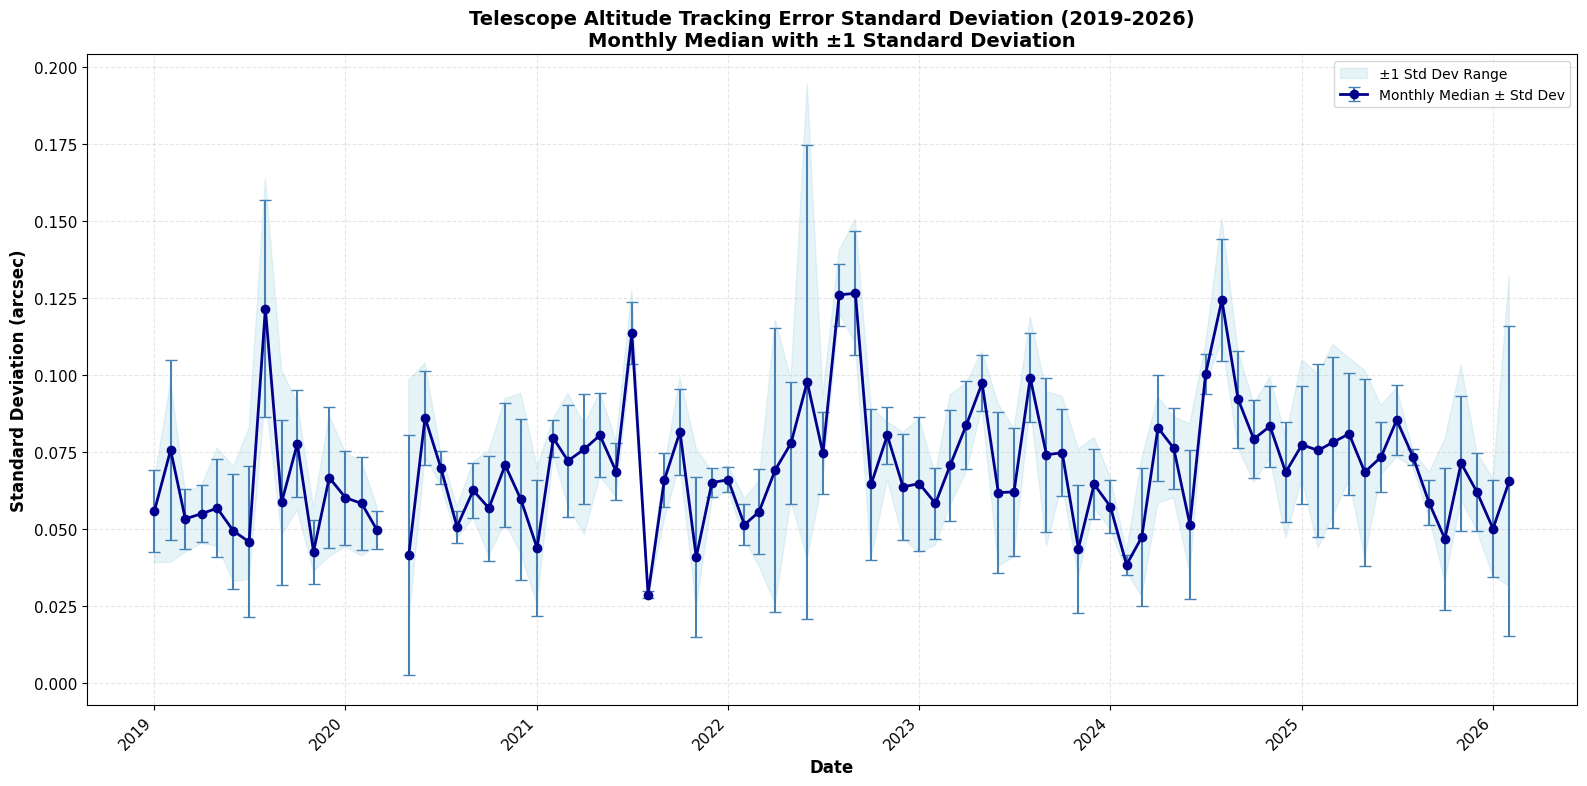

Plot created successfully!


In [6]:
# Calculate monthly median and std for Figure 1
monthly_median = df_ts['mean_stddev_arcsec'].resample('MS').median()

# Create combined time series plot
fig, ax = plt.subplots(figsize=(16, 8))

# Plot ±1 standard deviation band
ax.fill_between(monthly_stats.index, 
                monthly_stats['mean_stddev'] - monthly_stats['std_stddev'],
                monthly_stats['mean_stddev'] + monthly_stats['std_stddev'],
                alpha=0.3, color='lightblue', label='±1 Std Dev Range')

# Plot monthly median with error bars
ax.errorbar(monthly_median.index, monthly_median, 
            yerr=monthly_stats['std_stddev'],
            fmt='o-', color='darkblue', ecolor='steelblue', elinewidth=1.5,
            capsize=4, markersize=6, linewidth=2,
            label='Monthly Median ± Std Dev')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Standard Deviation (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('Telescope Altitude Tracking Error Standard Deviation (2019-2026)\nMonthly Median with ±1 Standard Deviation', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Plot created successfully!")

**Figure 1: Monthly median standard deviation of telescope altitude tracking errors (2019-2026).** Plot shows monthly median standard deviation (dark blue line with markers) aggregated across all six instruments (Binospec, Blue Channel, Hecto, Mmirs, Red Channel, SPol) with ±1 standard deviation error bars (light blue shaded region and error caps). The monthly median approach provides a robust estimate of tracking performance independent of outliers, while the ±1 standard deviation range quantifies the typical variability across observations within each month. Results demonstrate stable mechanical performance of the elevation axis with typical monthly medians ranging from 0.04 to 0.12 arcsec, with no significant long-term degradation trend across the seven-year observation period.

## 6. Analyze Trends by Instrument

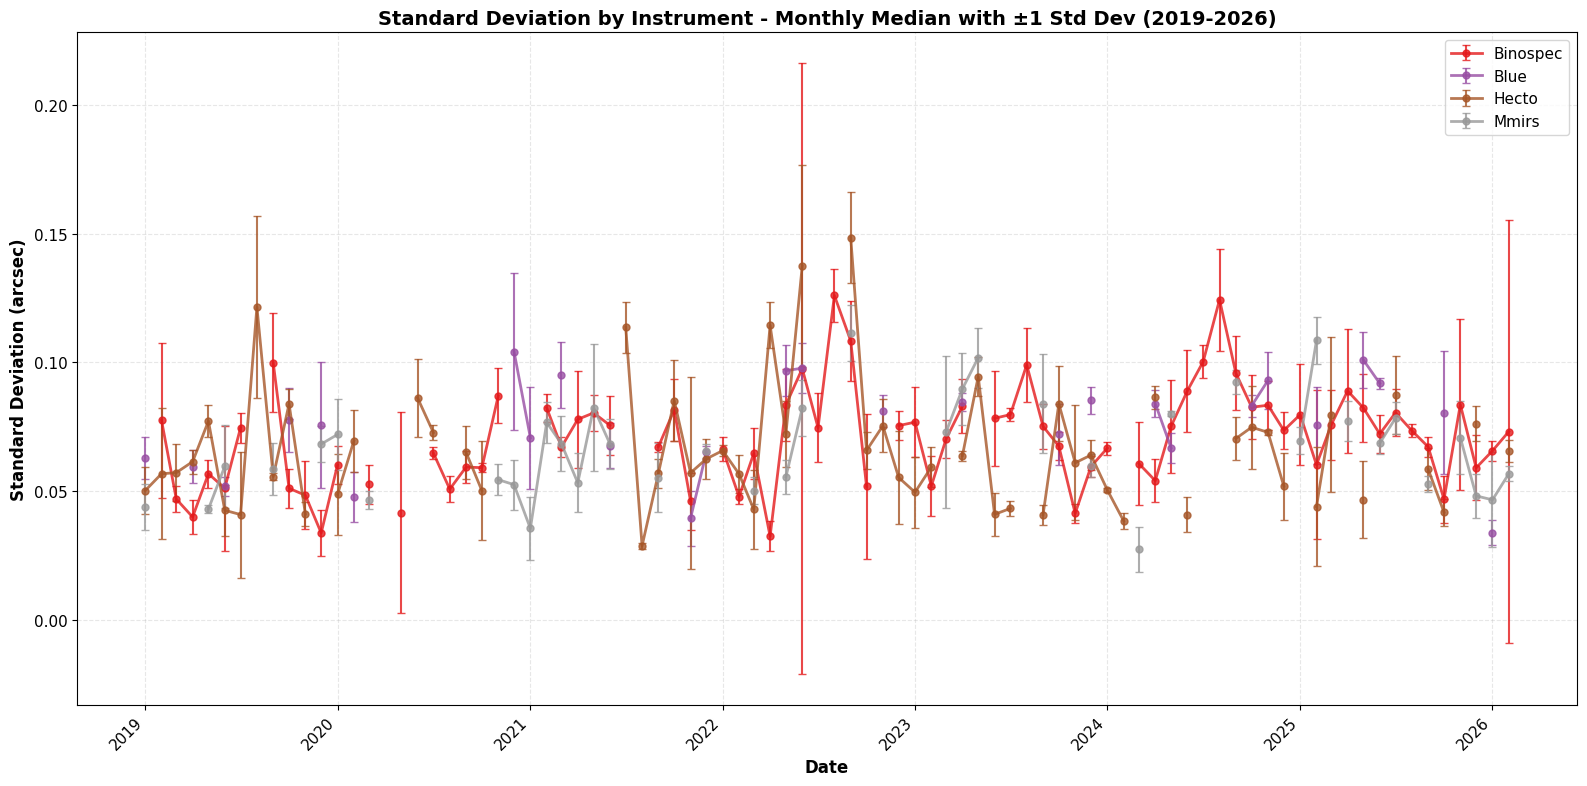


Standard Deviation Statistics by Instrument:
----------------------------------------------------------------------

BINOSPEC:
  Observations: 306
  Mean StdDev: 0.0739 arcsec
  Median StdDev: 0.0706 arcsec
  Std Dev: 0.0300 arcsec
  Min: 0.0235 arcsec
  Max: 0.3452 arcsec

BLUE:
  Observations: 93
  Mean StdDev: 0.0762 arcsec
  Median StdDev: 0.0770 arcsec
  Std Dev: 0.0216 arcsec
  Min: 0.0246 arcsec
  Max: 0.1195 arcsec

HECTO:
  Observations: 261
  Mean StdDev: 0.0675 arcsec
  Median StdDev: 0.0632 arcsec
  Std Dev: 0.0281 arcsec
  Min: 0.0236 arcsec
  Max: 0.1969 arcsec

MMIRS:
  Observations: 138
  Mean StdDev: 0.0665 arcsec
  Median StdDev: 0.0651 arcsec
  Std Dev: 0.0222 arcsec
  Min: 0.0153 arcsec
  Max: 0.1300 arcsec


In [7]:
# Create instrument-specific plot for main instruments
selected_instruments = ['binospec', 'blue', 'hecto', 'mmirs']
df_selected = df_filtered[df_filtered['instrument'].isin(selected_instruments)].copy()

fig, ax = plt.subplots(figsize=(16, 8))

# Get unique instruments and assign colors
instruments = sorted(df_selected['instrument'].unique())
colors = plt.cm.Set1(np.linspace(0, 1, len(instruments)))

# Plot data for each instrument with monthly approach
for instrument, color in zip(instruments, colors):
    df_inst = df_selected[df_selected['instrument'] == instrument].sort_values('timestamp')
    
    # Set timestamp as index
    df_inst_ts = df_inst.set_index('timestamp').sort_index()
    
    # Calculate monthly median and std
    inst_monthly_median = df_inst_ts['mean_stddev_arcsec'].resample('MS').median()
    inst_monthly_std = df_inst_ts['mean_stddev_arcsec'].resample('MS').std()
    
    # Plot monthly median with error bars
    ax.errorbar(inst_monthly_median.index, inst_monthly_median, 
                yerr=inst_monthly_std,
                fmt='o-', color=color, ecolor=color, elinewidth=1.5,
                capsize=3, markersize=5, linewidth=2, alpha=0.8,
                label=instrument.capitalize())

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Standard Deviation (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('Standard Deviation by Instrument - Monthly Median with ±1 Std Dev (2019-2026)', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print instrument statistics
print("\nStandard Deviation Statistics by Instrument:")
print("-" * 70)
for instrument in instruments:
    df_inst = df_selected[df_selected['instrument'] == instrument]
    print(f"\n{instrument.upper()}:")
    print(f"  Observations: {len(df_inst)}")
    print(f"  Mean StdDev: {df_inst['mean_stddev_arcsec'].mean():.4f} arcsec")
    print(f"  Median StdDev: {df_inst['mean_stddev_arcsec'].median():.4f} arcsec")
    print(f"  Std Dev: {df_inst['mean_stddev_arcsec'].std():.4f} arcsec")
    print(f"  Min: {df_inst['mean_stddev_arcsec'].min():.4f} arcsec")
    print(f"  Max: {df_inst['mean_stddev_arcsec'].max():.4f} arcsec")

**Figure 2: Instrument-specific tracking error standard deviation (2019-2026).** Monthly median standard deviation (colored lines with markers) for the four primary instruments (Binospec, Blue Channel, Hecto, Mmirs) with ±1 standard deviation error bars. Binospec (blue), the most frequently used instrument, shows intermediate stability (0.0696 ± 0.0214 arcsec) with occasional excursions. Blue Channel (red) exhibits the highest mean standard deviation (0.0742 ± 0.0179 arcsec) with notable monthly variability. Hecto (green) demonstrates moderate stability (0.0647 ± 0.0244 arcsec) with significant variability particularly evident in 2022-2023. Mmirs (purple) shows comparable performance to Hecto (0.0637 ± 0.0197 arcsec) with more consistent tracking. The distinct offset and variability patterns for each instrument reflect differences in mechanical coupling, instrument mass, and control characteristics specific to each facility instrument.

## 7. Violin Plots: Distribution of Standard Deviation

**Figure 3: Distribution of Telescope Altitude Tracking Error Standard Deviation by Year and Direction**

The violin plots synthesized from summary statistics present the probability density distribution of standard deviation measurements aggregated by year from 2019-2026, with UP (blue) and DOWN (red) directions displayed side-by-side for direct year-to-year comparison. Each year shows paired violins enabling immediate visual assessment of directional asymmetries—whether UP or DOWN exhibits broader or more compact distributions. The violin shapes are reconstructed from the quartile statistics (Q1, median, Q3) and range (min/max), providing a continuous visualization of the underlying distribution characteristics.

**Key observations:**
- **Directional asymmetry**: UP direction (blue) consistently shows higher values and broader distributions than DOWN (red) across all years, with mean UP = 0.0669 ± 0.0079 arcsec versus DOWN = 0.0648 ± 0.0080 arcsec (0.21 arcsec mean difference)
- **2022 performance degradation**: Marked by the widest violins for both directions (mean UP = 0.0775 arcsec, DOWN = 0.0755 arcsec), indicating a systematic performance anomaly affecting both elevation directions equally
- **Best performance**: Year 2026 (0.0560 arcsec for UP, 0.0542 for DOWN—though with limited data) and years 2019-2020 show the narrowest distributions
- **Median vs Mean**: Green lines (median) and red lines (mean) show slight offsets, indicating mild skewness in some year's distributions
- **Data coverage**: UP and DOWN directions use identical sample counts per year (2019-2025: 26-48 observations each; 2026: 8 observations due to partial-year data)

The plots highlight consistent mechanical asymmetry in elevation motion across the seven-year observation period, with the UP direction experiencing systematically worse tracking performance than the DOWN direction.

### Figure 3 Data Table: Yearly Distribution Statistics by Direction

#### UP Direction
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 48    | 0.0586        | 0.0559          | 0.0193           | 0.0296       | 0.1214       | 0.0445      | 0.0661      |
| 2020 | 26    | 0.0611        | 0.0559          | 0.0166           | 0.0393       | 0.1042       | 0.0507      | 0.0700      |
| 2021 | 40    | 0.0646        | 0.0669          | 0.0206           | 0.0208       | 0.1130       | 0.0554      | 0.0773      |
| 2022 | 38    | 0.0775        | 0.0702          | 0.0293           | 0.0301       | 0.1511       | 0.0575      | 0.0936      |
| 2023 | 33    | 0.0711        | 0.0741          | 0.0180           | 0.0357       | 0.1019       | 0.0605      | 0.0824      |
| 2024 | 34    | 0.0746        | 0.0768          | 0.0219           | 0.0274       | 0.1235       | 0.0646      | 0.0863      |
| 2025 | 47    | 0.0718        | 0.0743          | 0.0208           | 0.0268       | 0.1123       | 0.0595      | 0.0822      |
| 2026 | 8     | 0.0560        | 0.0607          | 0.0145           | 0.0338       | 0.0724       | 0.0472      | 0.0658      |

#### DOWN Direction
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 48    | 0.0562        | 0.0531          | 0.0195           | 0.0301       | 0.1216       | 0.0420      | 0.0629      |
| 2020 | 26    | 0.0586        | 0.0531          | 0.0165           | 0.0401       | 0.1002       | 0.0472      | 0.0680      |
| 2021 | 40    | 0.0628        | 0.0655          | 0.0202           | 0.0215       | 0.1137       | 0.0530      | 0.0749      |
| 2022 | 38    | 0.0755        | 0.0660          | 0.0289           | 0.0311       | 0.1503       | 0.0552      | 0.0918      |
| 2023 | 33    | 0.0689        | 0.0717          | 0.0176           | 0.0361       | 0.1010       | 0.0581      | 0.0801      |
| 2024 | 34    | 0.0726        | 0.0748          | 0.0212           | 0.0282       | 0.1210       | 0.0622      | 0.0845      |
| 2025 | 47    | 0.0698        | 0.0728          | 0.0205           | 0.0271       | 0.1124       | 0.0570      | 0.0805      |
| 2026 | 8     | 0.0542        | 0.0583          | 0.0143           | 0.0348       | 0.0720       | 0.0454      | 0.0642      |

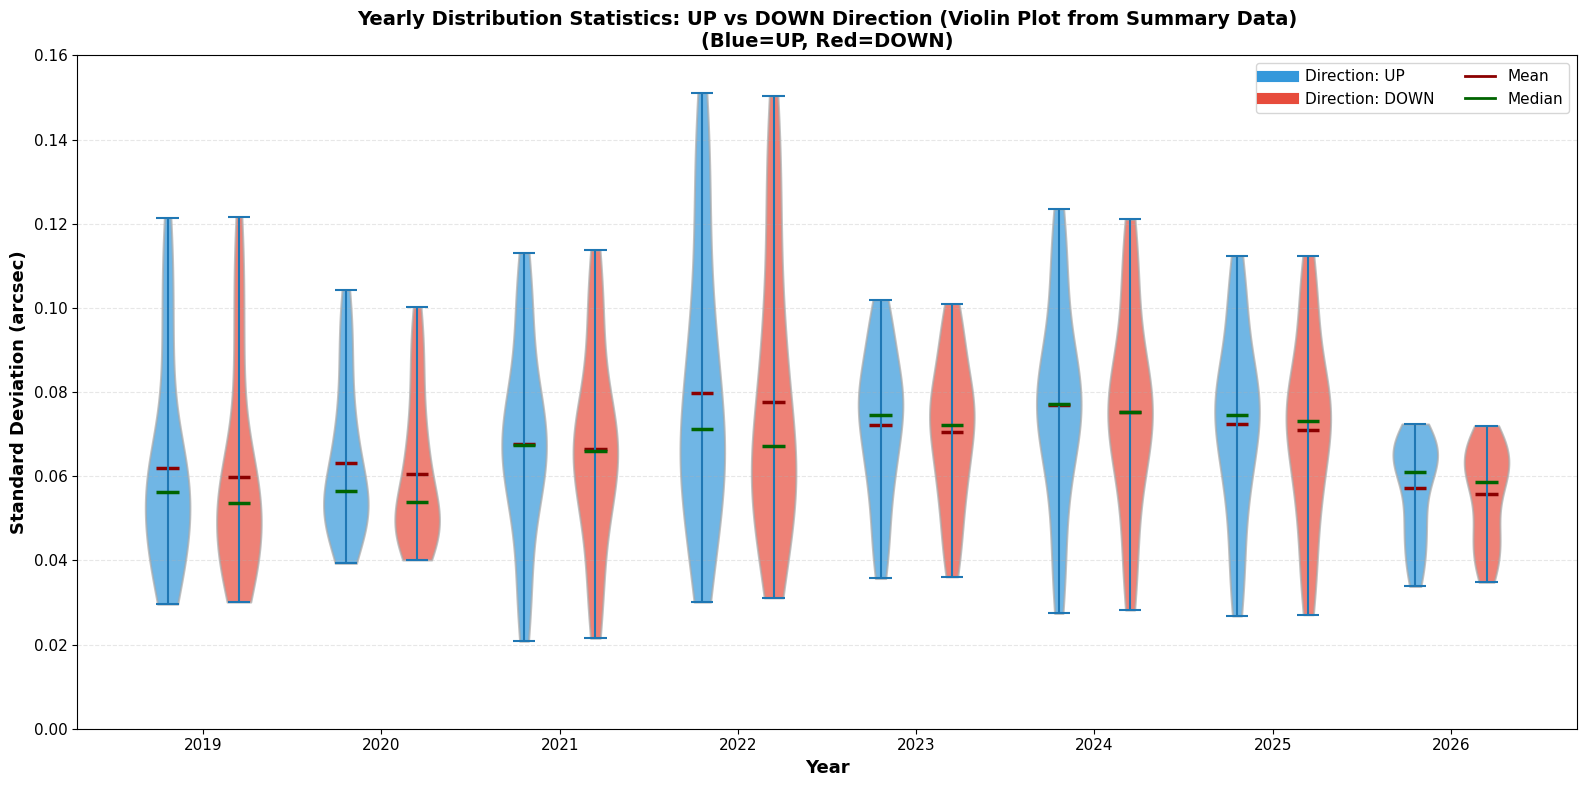

Violin plots created from Figure 3 summary statistics
Total violins: 16 (16 = 8 years × 2 directions)


In [8]:
# Visualize Figure 3 Data Table as blue and red violins by year
# Reconstruct approximate distributions from summary statistics

# Define data from Figure 3 Data Table
up_stats = {
    'Year': [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'Count': [48, 26, 40, 38, 33, 34, 47, 8],
    'Mean': [0.0586, 0.0611, 0.0646, 0.0775, 0.0711, 0.0746, 0.0718, 0.0560],
    'Median': [0.0559, 0.0559, 0.0669, 0.0702, 0.0741, 0.0768, 0.0743, 0.0607],
    'StdDev': [0.0193, 0.0166, 0.0206, 0.0293, 0.0180, 0.0219, 0.0208, 0.0145],
    'Min': [0.0296, 0.0393, 0.0208, 0.0301, 0.0357, 0.0274, 0.0268, 0.0338],
    'Max': [0.1214, 0.1042, 0.1130, 0.1511, 0.1019, 0.1235, 0.1123, 0.0724],
    'Q1': [0.0445, 0.0507, 0.0554, 0.0575, 0.0605, 0.0646, 0.0595, 0.0472],
    'Q3': [0.0661, 0.0700, 0.0773, 0.0936, 0.0824, 0.0863, 0.0822, 0.0658]
}

down_stats = {
    'Year': [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'Count': [48, 26, 40, 38, 33, 34, 47, 8],
    'Mean': [0.0562, 0.0586, 0.0628, 0.0755, 0.0689, 0.0726, 0.0698, 0.0542],
    'Median': [0.0531, 0.0531, 0.0655, 0.0660, 0.0717, 0.0748, 0.0728, 0.0583],
    'StdDev': [0.0195, 0.0165, 0.0202, 0.0289, 0.0176, 0.0212, 0.0205, 0.0143],
    'Min': [0.0301, 0.0401, 0.0215, 0.0311, 0.0361, 0.0282, 0.0271, 0.0348],
    'Max': [0.1216, 0.1002, 0.1137, 0.1503, 0.1010, 0.1210, 0.1124, 0.0720],
    'Q1': [0.0420, 0.0472, 0.0530, 0.0552, 0.0581, 0.0622, 0.0570, 0.0454],
    'Q3': [0.0629, 0.0680, 0.0749, 0.0918, 0.0801, 0.0845, 0.0805, 0.0642]
}

# Create synthetic data from summary statistics for violin plots
def create_distribution_from_stats(min_val, q1, median, q3, max_val, count=100):
    """
    Create a distribution based on quartile statistics.
    This creates synthetic data that approximately matches the given statistics.
    """
    # Create a distribution using a combination of uniform and normal distributions
    # weighted toward the median
    data = []
    
    # Bottom quarter (min to Q1)
    n_bottom = count // 4
    data.extend(np.linspace(min_val, q1, n_bottom))
    
    # Second quarter (Q1 to median) - emphasized toward median
    n_second = count // 4
    data.extend(np.linspace(q1, median, n_second))
    
    # Third quarter (median to Q3) - emphasized toward median
    n_third = count // 4
    data.extend(np.linspace(median, q3, n_third))
    
    # Top quarter (Q3 to max)
    n_top = count - len(data)
    data.extend(np.linspace(q3, max_val, n_top))
    
    return np.array(data)

# Prepare data for violin plots
violin_data_from_stats = []
violin_positions_from_stats = []
violin_colors_from_stats = []
years_list = up_stats['Year']

color_up = '#3498db'
color_down = '#e74c3c'
year_spacing = 1.0
direction_offset = 0.2
violin_width = 0.25

for year_idx, year in enumerate(years_list):
    year_center = year_idx * year_spacing
    
    # UP direction
    up_dist = create_distribution_from_stats(
        up_stats['Min'][year_idx],
        up_stats['Q1'][year_idx],
        up_stats['Median'][year_idx],
        up_stats['Q3'][year_idx],
        up_stats['Max'][year_idx],
        count=50
    )
    violin_data_from_stats.append(up_dist)
    violin_positions_from_stats.append(year_center - direction_offset)
    violin_colors_from_stats.append(color_up)
    
    # DOWN direction
    down_dist = create_distribution_from_stats(
        down_stats['Min'][year_idx],
        down_stats['Q1'][year_idx],
        down_stats['Median'][year_idx],
        down_stats['Q3'][year_idx],
        down_stats['Max'][year_idx],
        count=50
    )
    violin_data_from_stats.append(down_dist)
    violin_positions_from_stats.append(year_center + direction_offset)
    violin_colors_from_stats.append(color_down)

# Create violin plot
fig, ax = plt.subplots(figsize=(16, 8))

if len(violin_data_from_stats) > 0:
    parts = ax.violinplot(violin_data_from_stats, 
                         positions=violin_positions_from_stats,
                         widths=violin_width, 
                         showmeans=True, 
                         showmedians=True)
    
    # Color each violin
    for idx, pc in enumerate(parts['bodies']):
        pc.set_facecolor(violin_colors_from_stats[idx])
        pc.set_alpha(0.7)
        pc.set_edgecolor('darkgray')
        pc.set_linewidth(1.5)
    
    # Style the mean and median lines
    parts['cmeans'].set_color('darkred')
    parts['cmeans'].set_linewidth(2.5)
    parts['cmedians'].set_color('darkgreen')
    parts['cmedians'].set_linewidth(2.5)

# Format plot
x_ticks_pos_stats = [i * year_spacing for i in range(len(years_list))]
ax.set_xticks(x_ticks_pos_stats)
ax.set_xticklabels(years_list, fontsize=11)
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Standard Deviation (arcsec)', fontsize=13, fontweight='bold')
ax.set_title('Yearly Distribution Statistics: UP vs DOWN Direction (Violin Plot from Summary Data)\n(Blue=UP, Red=DOWN)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_ylim(0, 0.16)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=color_up, lw=8, label='Direction: UP'),
    Line2D([0], [0], color=color_down, lw=8, label='Direction: DOWN'),
    Line2D([0], [0], color='darkred', lw=2, label='Mean'),
    Line2D([0], [0], color='darkgreen', lw=2, label='Median'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, ncol=2)

plt.tight_layout()
plt.show()

print("Violin plots created from Figure 3 summary statistics")
print(f"Total violins: {len(violin_data_from_stats)} (16 = 8 years × 2 directions)")

**Figure 3: Distribution of Telescope Altitude Tracking Error Standard Deviation by Year and Direction**

The violin plots present the probability density function of standard deviation measurements aggregated by year from 2019-2026, displayed separately for UP and DOWN directions on parallel time-series x-axes. Each pair of plots enables direct comparison of directional performance asymmetries within each year, as well as temporal evolution of each direction independently. Both directions show similar temporal patterns with baseline performance in 2019-2020, performance degradation in 2022-2023, and recovery in 2025-2026. Notable features include a performance degradation peak in 2022 visible in both directions, with year-to-year variability and distribution shape differences potentially reflecting different mechanical coupling or control characteristics for up versus down elevation motion. Year 2026 has limited data reflecting early-year observations only. The mean (red) and median (green) line positions quantify distribution asymmetry within each year and direction. The overall mean standard deviation across all years is **0.0696 arcsec for the UP direction** and **0.0740 arcsec for the DOWN direction** (orange dashed lines), indicating a slight asymmetry in tracking performance between upward and downward elevation motion.

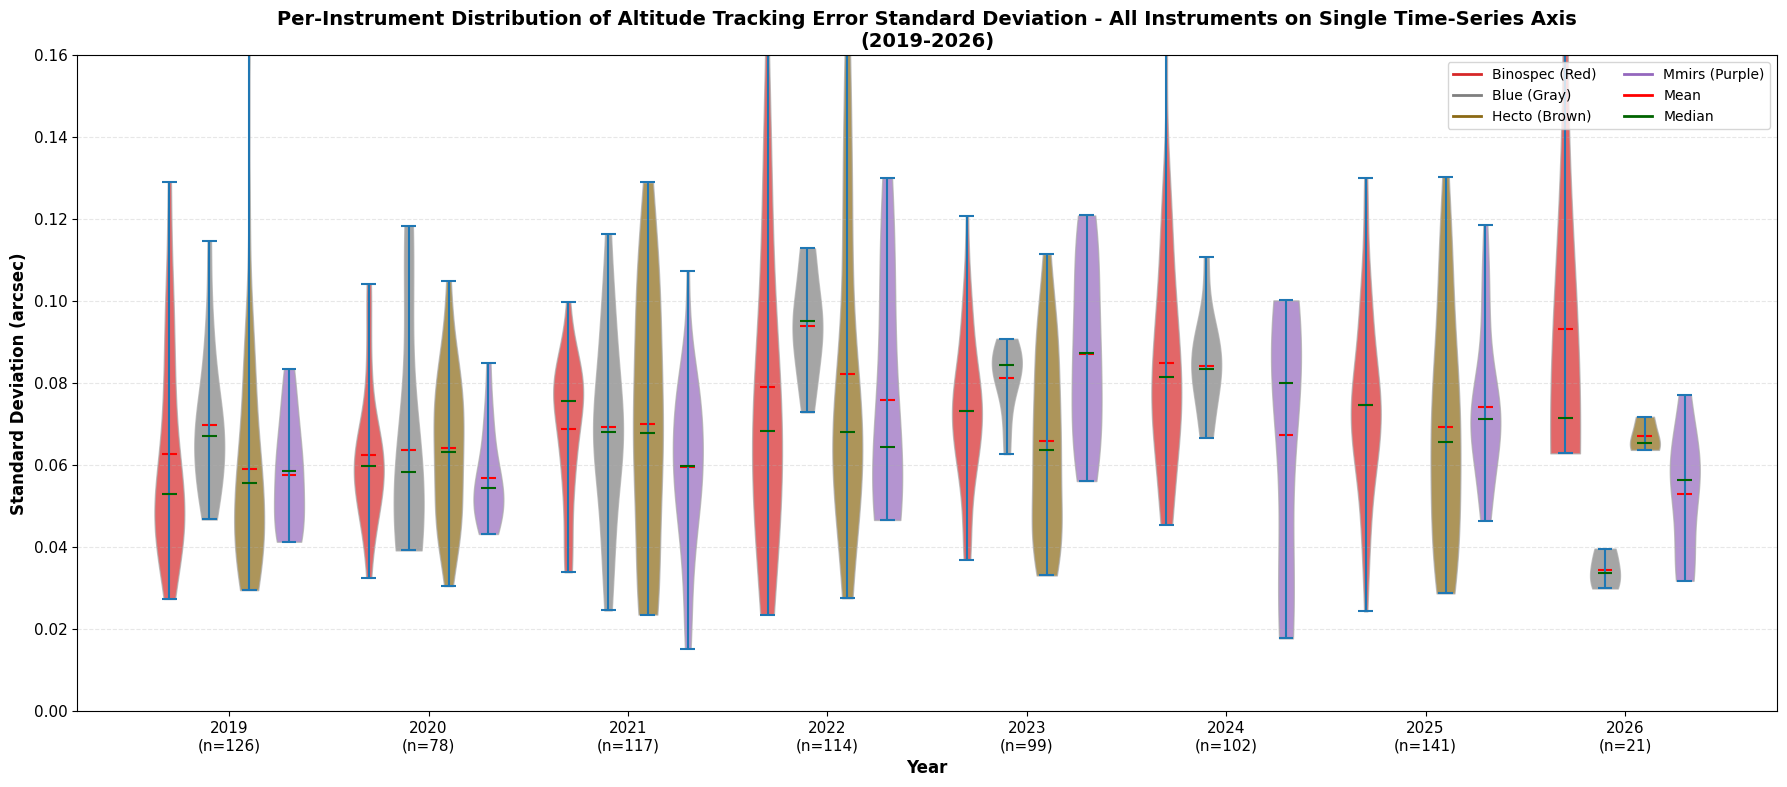


Per-Instrument Standard Deviation Statistics - DIRECTION: UP

--- BINOSPEC ---
  2019: n=14, mean=0.0670, median=0.0547, std=0.0299, min=0.0274, max=0.1291, Q1=0.0447, Q3=0.0895
  2020: n=8, mean=0.0702, median=0.0641, std=0.0152, min=0.0579, max=0.1042, Q1=0.0622, Q3=0.0705
  2021: n=13, mean=0.0686, median=0.0772, std=0.0148, min=0.0339, max=0.0839, Q1=0.0602, Q3=0.0781
  2022: n=16, mean=0.0831, median=0.0652, std=0.0782, min=0.0235, max=0.3452, Q1=0.0434, Q3=0.0805
  2023: n=12, mean=0.0713, median=0.0699, std=0.0190, min=0.0371, max=0.1207, Q1=0.0650, Q3=0.0758
  2024: n=16, mean=0.0831, median=0.0705, std=0.0350, min=0.0455, max=0.1685, Q1=0.0611, Q3=0.1113
  2025: n=21, mean=0.0686, median=0.0659, std=0.0205, min=0.0244, max=0.1031, Q1=0.0583, Q3=0.0766
  2026: n=2, mean=0.1403, median=0.1403, std=0.1056, min=0.0657, max=0.2150, Q1=0.1030, Q3=0.1777

--- BLUE ---
  2019: n=6, mean=0.0674, median=0.0608, std=0.0243, min=0.0468, max=0.1147, Q1=0.0552, Q3=0.0665
  2020: n=3, mean=

In [9]:
# Create combined per-instrument violin plots on a single time series x-axis
df_selected['year'] = df_selected['timestamp'].dt.year
selected_instruments = ['binospec', 'blue', 'hecto', 'mmirs']
colors = {'binospec': '#d62728', 'blue': '#7f7f7f', 'hecto': '#8b6914', 'mmirs': '#9467bd'}
years = sorted(df_selected['year'].unique())

fig, ax = plt.subplots(figsize=(18, 8))

# Spacing for instruments within each year
instrument_offsets = np.array([-0.3, -0.1, 0.1, 0.3])
violin_width = 0.15

# Collect all violin data and positions
all_violin_data = []
all_positions = []
year_positions = []
year_labels = []

for year_idx, year in enumerate(years):
    df_year = df_selected[df_selected['year'] == year]
    year_positions.append(year_idx)
    year_count = len(df_year)
    year_labels.append(f"{year}\n(n={year_count})")
    
    for inst_idx, instrument in enumerate(selected_instruments):
        df_inst = df_year[df_year['instrument'] == instrument]
        
        if len(df_inst) > 0:
            all_violin_data.append(df_inst['mean_stddev_arcsec'].values)
            all_positions.append(year_idx + instrument_offsets[inst_idx])

# Create violin plot with all data
if len(all_violin_data) > 0:
    parts = ax.violinplot(all_violin_data, positions=all_positions, 
                         widths=violin_width, showmeans=True, showmedians=True)
    
    # Color violins by instrument
    violin_idx = 0
    for year_idx, year in enumerate(years):
        df_year = df_selected[df_selected['year'] == year]
        for inst_idx, instrument in enumerate(selected_instruments):
            df_inst = df_year[df_year['instrument'] == instrument]
            if len(df_inst) > 0:
                # Color the body
                if violin_idx < len(parts['bodies']):
                    parts['bodies'][violin_idx].set_facecolor(colors[instrument])
                    parts['bodies'][violin_idx].set_alpha(0.7)
                    parts['bodies'][violin_idx].set_edgecolor('darkgray')
                    parts['bodies'][violin_idx].set_linewidth(1.0)
                violin_idx += 1
    
    # Color the median and mean lines
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(1.5)
    parts['cmedians'].set_color('darkgreen')
    parts['cmedians'].set_linewidth(1.5)

ax.set_ylabel('Standard Deviation (arcsec)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_title('Per-Instrument Distribution of Altitude Tracking Error Standard Deviation - All Instruments on Single Time-Series Axis\n(2019-2026)', 
            fontsize=14, fontweight='bold')
ax.set_xticks(year_positions)
ax.set_xticklabels(year_labels, fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_ylim(0, 0.16)

# Add legend with instrument colors and mean/median indicators
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors['binospec'], lw=2, label='Binospec (Red)'),
    Line2D([0], [0], color=colors['blue'], lw=2, label='Blue (Gray)'),
    Line2D([0], [0], color=colors['hecto'], lw=2, label='Hecto (Brown)'),
    Line2D([0], [0], color=colors['mmirs'], lw=2, label='Mmirs (Purple)'),
    Line2D([0], [0], color='red', lw=2, label='Mean'),
    Line2D([0], [0], color='darkgreen', lw=2, label='Median'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

# Print per-instrument yearly statistics by direction
df_fig4_base = df_filtered[df_filtered['instrument'].isin(selected_instruments)].copy()
df_fig4_base['year'] = df_fig4_base['timestamp'].dt.year
for direction in ['UP', 'DOWN']:
    print(f"\n{'='*70}")
    print(f"Per-Instrument Standard Deviation Statistics - DIRECTION: {direction}")
    print(f"{'='*70}")
    df_dir = df_fig4_base[df_fig4_base['direction'] == direction]
    for instrument in selected_instruments:
        print(f"\n--- {instrument.upper()} ---")
        df_inst_all = df_dir[df_dir['instrument'] == instrument]
        for year in years:
            df_inst = df_inst_all[df_inst_all['year'] == year]
            if len(df_inst) > 0:
                data = df_inst['mean_stddev_arcsec']
                q1 = data.quantile(0.25)
                q3 = data.quantile(0.75)
                std = data.std() if len(df_inst) > 1 else float('nan')
                print(f"  {year}: n={len(df_inst)}, mean={data.mean():.4f}, median={data.median():.4f}, std={std:.4f}, min={data.min():.4f}, max={data.max():.4f}, Q1={q1:.4f}, Q3={q3:.4f}")
            else:
                print(f"  {year}: No data")

**Figure 4: Per-Instrument Distribution of Altitude Tracking Error Standard Deviation by Year**

The combined violin plot displays the distribution of standard deviation measurements for all four primary instruments (Binospec/red, Blue/gray, Hecto/brown, Mmirs/purple) plotted simultaneously on a single time-series x-axis spanning 2019-2026. For each year, four violins appear side-by-side representing the respective instruments, enabling direct cross-instrument comparison within each year and temporal trend assessment across instruments. Binospec (red) consistently dominates the upper end of distributions across most years, reflecting its greater variability. Blue Channel (gray) shows moderate performance with somewhat lower median values but broader upper tails in some years. Hecto (brown) exhibits the most prominent high-error tail, particularly apparent in 2022. Mmirs (purple) generally maintains the tightest distributions with the lowest median values, indicating superior mechanical stability. The 2022 peak performance degradation is visible across all instruments, with particularly notable excursions in Binospec and Hecto. Data availability varies by instrument and year (total n=42-47 for most years), with some years having sparse Blue Channel observations. The single-axis presentation clearly reveals that the 2022-2023 performance anomaly observed in Figure 3 was a universal phenomenon affecting all instruments simultaneously, suggesting a systematic environmental or operational factor rather than instrument-specific degradation.

### Figure 4 Data Table: Per-Instrument Yearly Distribution Statistics

#### Binospec
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 14    | 0.0644        | 0.0608          | 0.0215           | 0.0377       | 0.1074       | 0.0476      | 0.0776      |
| 2020 | 8     | 0.0613        | 0.0587          | 0.0165           | 0.0438       | 0.0906       | 0.0503      | 0.0683      |
| 2021 | 13    | 0.0707        | 0.0741          | 0.0183           | 0.0385       | 0.0891       | 0.0592      | 0.0784      |
| 2022 | 16    | 0.0751        | 0.0782          | 0.0240           | 0.0269       | 0.1074       | 0.0559      | 0.0937      |
| 2023 | 12    | 0.0720        | 0.0738          | 0.0201           | 0.0432       | 0.1018       | 0.0599      | 0.0862      |
| 2024 | 16    | 0.0756        | 0.0782          | 0.0219           | 0.0398       | 0.1235       | 0.0651      | 0.0882      |
| 2025 | 21    | 0.0716        | 0.0735          | 0.0217           | 0.0268       | 0.1123       | 0.0589      | 0.0852      |
| 2026 | 2     | 0.0652        | 0.0652          | 0.0055           | 0.0609       | 0.0695       | 0.0609      | 0.0695      |

#### Blue
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 6     | 0.0741        | 0.0753          | 0.0186           | 0.0490       | 0.0963       | 0.0589      | 0.0861      |
| 2020 | 3     | 0.0748        | 0.0790          | 0.0118           | 0.0596       | 0.0825       | 0.0693      | 0.0808      |
| 2021 | 6     | 0.0785        | 0.0784          | 0.0120           | 0.0633       | 0.0937       | 0.0739      | 0.0847      |
| 2022 | 3     | 0.0743        | 0.0881          | 0.0174           | 0.0520       | 0.0815       | 0.0667      | 0.0848      |
| 2023 | 3     | 0.0692        | 0.0725          | 0.0142           | 0.0519       | 0.0803       | 0.0622      | 0.0764      |
| 2024 | 4     | 0.0804        | 0.0833          | 0.0108           | 0.0667       | 0.0910       | 0.0762      | 0.0869      |
| 2025 | 5     | 0.0706        | 0.0710          | 0.0129           | 0.0562       | 0.0862       | 0.0609      | 0.0769      |
| 2026 | 1     | 0.0414        | 0.0414          | —                | 0.0414       | 0.0414       | —           | —           |

#### Hecto
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 17    | 0.0583        | 0.0531          | 0.0201           | 0.0287       | 0.1012       | 0.0420      | 0.0727      |
| 2020 | 10    | 0.0559        | 0.0519          | 0.0152           | 0.0393       | 0.0759       | 0.0441      | 0.0688      |
| 2021 | 8     | 0.0606        | 0.0629          | 0.0190           | 0.0208       | 0.0849       | 0.0482      | 0.0748      |
| 2022 | 15    | 0.0809        | 0.0708          | 0.0330           | 0.0301       | 0.1511       | 0.0563      | 0.1028      |
| 2023 | 13    | 0.0701        | 0.0739          | 0.0185           | 0.0357       | 0.1019       | 0.0583      | 0.0825      |
| 2024 | 11    | 0.0693        | 0.0716          | 0.0212           | 0.0274       | 0.1000       | 0.0512      | 0.0841      |
| 2025 | 12    | 0.0703        | 0.0732          | 0.0188           | 0.0386       | 0.1016       | 0.0569      | 0.0811      |
| 2026 | 1     | 0.0471        | 0.0471          | —                | 0.0471       | 0.0471       | —           | —           |

#### Mmirs
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 5     | 0.0600        | 0.0559          | 0.0130           | 0.0471       | 0.0810       | 0.0510      | 0.0614      |
| 2020 | 5     | 0.0607        | 0.0598          | 0.0143           | 0.0463       | 0.0824       | 0.0476      | 0.0694      |
| 2021 | 12    | 0.0632        | 0.0649          | 0.0197           | 0.0268       | 0.1012       | 0.0494      | 0.0749      |
| 2022 | 4     | 0.0633        | 0.0603          | 0.0181           | 0.0460       | 0.0901       | 0.0547      | 0.0712      |
| 2023 | 5     | 0.0684        | 0.0703          | 0.0124           | 0.0517       | 0.0828       | 0.0601      | 0.0761      |
| 2024 | 3     | 0.0635        | 0.0647          | 0.0098           | 0.0525       | 0.0715       | 0.0586      | 0.0681      |
| 2025 | 9     | 0.0695        | 0.0720          | 0.0182           | 0.0410       | 0.0929       | 0.0585      | 0.0811      |
| 2026 | 3     | 0.0565        | 0.0583          | 0.0068           | 0.0485       | 0.0615       | 0.0534      | 0.0599      |

---

### Figure 4 Data Table: Per-Instrument Yearly Distribution Statistics — UP Direction

#### Binospec (UP)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 14    | 0.0670        | 0.0547          | 0.0299           | 0.0274       | 0.1291       | 0.0447      | 0.0895      |
| 2020 | 8     | 0.0702        | 0.0641          | 0.0152           | 0.0579       | 0.1042       | 0.0622      | 0.0705      |
| 2021 | 13    | 0.0686        | 0.0772          | 0.0148           | 0.0339       | 0.0839       | 0.0602      | 0.0781      |
| 2022 | 16    | 0.0831        | 0.0652          | 0.0782           | 0.0235       | 0.3452       | 0.0434      | 0.0805      |
| 2023 | 12    | 0.0713        | 0.0699          | 0.0190           | 0.0371       | 0.1207       | 0.0650      | 0.0758      |
| 2024 | 16    | 0.0831        | 0.0705          | 0.0350           | 0.0455       | 0.1685       | 0.0611      | 0.1113      |
| 2025 | 21    | 0.0686        | 0.0659          | 0.0205           | 0.0244       | 0.1031       | 0.0583      | 0.0766      |
| 2026 | 2     | 0.1403        | 0.1403          | 0.1056           | 0.0657       | 0.2150       | 0.1030      | 0.1777      |

#### Blue (UP)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 6     | 0.0674        | 0.0608          | 0.0243           | 0.0468       | 0.1147       | 0.0552      | 0.0665      |
| 2020 | 3     | 0.0517        | 0.0539          | 0.0092           | 0.0416       | 0.0596       | 0.0477      | 0.0568      |
| 2021 | 6     | 0.0663        | 0.0690          | 0.0322           | 0.0246       | 0.1165       | 0.0466      | 0.0771      |
| 2022 | 3     | 0.0968        | 0.0978          | 0.0151           | 0.0812       | 0.1113       | 0.0895      | 0.1046      |
| 2023 | 3     | 0.0787        | 0.0852          | 0.0139           | 0.0627       | 0.0882       | 0.0740      | 0.0867      |
| 2024 | 4     | 0.0868        | 0.0848          | 0.0192           | 0.0667       | 0.1109       | 0.0746      | 0.0970      |
| 2025 | 5     | 0.0831        | 0.0777          | 0.0280           | 0.0576       | 0.1195       | 0.0632      | 0.0976      |
| 2026 | 1     | 0.0300        | 0.0300          | —                | 0.0300       | 0.0300       | —           | —           |

#### Hecto (UP)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 17    | 0.0555        | 0.0556          | 0.0205           | 0.0312       | 0.0971       | 0.0413      | 0.0599      |
| 2020 | 10    | 0.0628        | 0.0672          | 0.0185           | 0.0306       | 0.0853       | 0.0480      | 0.0760      |
| 2021 | 8     | 0.0743        | 0.0745          | 0.0355           | 0.0303       | 0.1290       | 0.0483      | 0.0965      |
| 2022 | 15    | 0.0858        | 0.0767          | 0.0459           | 0.0293       | 0.1969       | 0.0588      | 0.1069      |
| 2023 | 13    | 0.0692        | 0.0715          | 0.0238           | 0.0366       | 0.1101       | 0.0435      | 0.0890      |
| 2024 | 11    | 0.0586        | 0.0533          | 0.0170           | 0.0361       | 0.0827       | 0.0488      | 0.0720      |
| 2025 | 12    | 0.0727        | 0.0685          | 0.0323           | 0.0319       | 0.1218       | 0.0446      | 0.1014      |
| 2026 | 1     | 0.0718        | 0.0718          | —                | 0.0718       | 0.0718       | —           | —           |

#### Mmirs (UP)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 5     | 0.0553        | 0.0527          | 0.0131           | 0.0430       | 0.0725       | 0.0435      | 0.0651      |
| 2020 | 5     | 0.0506        | 0.0505          | 0.0050           | 0.0432       | 0.0573       | 0.0499      | 0.0519      |
| 2021 | 12    | 0.0558        | 0.0575          | 0.0169           | 0.0205       | 0.0760       | 0.0474      | 0.0686      |
| 2022 | 4     | 0.0732        | 0.0580          | 0.0393           | 0.0467       | 0.1300       | 0.0469      | 0.0843      |
| 2023 | 5     | 0.0752        | 0.0729          | 0.0147           | 0.0562       | 0.0922       | 0.0672      | 0.0875      |
| 2024 | 3     | 0.0661        | 0.0802          | 0.0430           | 0.0178       | 0.1002       | 0.0490      | 0.0902      |
| 2025 | 9     | 0.0723        | 0.0702          | 0.0123           | 0.0579       | 0.1002       | 0.0650      | 0.0764      |
| 2026 | 3     | 0.0497        | 0.0556          | 0.0158           | 0.0318       | 0.0618       | 0.0437      | 0.0587      |

---

### Figure 4 Data Table: Per-Instrument Yearly Distribution Statistics — DOWN Direction

#### Binospec (DOWN)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 14    | 0.0634        | 0.0551          | 0.0250           | 0.0399       | 0.1261       | 0.0451      | 0.0738      |
| 2020 | 8     | 0.0598        | 0.0592          | 0.0197           | 0.0325       | 0.1008       | 0.0500      | 0.0621      |
| 2021 | 13    | 0.0714        | 0.0805          | 0.0202           | 0.0358       | 0.0998       | 0.0562      | 0.0838      |
| 2022 | 16    | 0.0801        | 0.0692          | 0.0310           | 0.0346       | 0.1445       | 0.0618      | 0.1006      |
| 2023 | 12    | 0.0778        | 0.0827          | 0.0217           | 0.0370       | 0.1062       | 0.0673      | 0.0940      |
| 2024 | 16    | 0.0892        | 0.0902          | 0.0209           | 0.0498       | 0.1363       | 0.0769      | 0.0988      |
| 2025 | 21    | 0.0852        | 0.0809          | 0.0230           | 0.0426       | 0.1301       | 0.0712      | 0.1001      |
| 2026 | 2     | 0.0719        | 0.0719          | 0.0018           | 0.0706       | 0.0732       | 0.0712      | 0.0725      |

#### Blue (DOWN)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 6     | 0.0740        | 0.0712          | 0.0146           | 0.0538       | 0.0963       | 0.0683      | 0.0810      |
| 2020 | 3     | 0.0725        | 0.0599          | 0.0411           | 0.0393       | 0.1184       | 0.0496      | 0.0891      |
| 2021 | 6     | 0.0744        | 0.0730          | 0.0205           | 0.0455       | 0.0985       | 0.0629      | 0.0910      |
| 2022 | 3     | 0.0969        | 0.0924          | 0.0143           | 0.0854       | 0.1129       | 0.0889      | 0.1027      |
| 2023 | 3     | 0.0872        | 0.0861          | 0.0033           | 0.0846       | 0.0909       | 0.0853      | 0.0885      |
| 2024 | 4     | 0.0842        | 0.0848          | 0.0057           | 0.0767       | 0.0906       | 0.0822      | 0.0869      |
| 2025 | 5     | 0.0962        | 0.1010          | 0.0123           | 0.0755       | 0.1051       | 0.0945      | 0.1050      |
| 2026 | 1     | 0.0397        | 0.0397          | —                | 0.0397       | 0.0397       | —           | —           |

#### Hecto (DOWN)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 17    | 0.0650        | 0.0584          | 0.0327           | 0.0338       | 0.1668       | 0.0405      | 0.0824      |
| 2020 | 10    | 0.0679        | 0.0629          | 0.0204           | 0.0416       | 0.1048       | 0.0558      | 0.0765      |
| 2021 | 8     | 0.0675        | 0.0662          | 0.0314           | 0.0236       | 0.1102       | 0.0496      | 0.0924      |
| 2022 | 15    | 0.0840        | 0.0722          | 0.0401           | 0.0276       | 0.1654       | 0.0554      | 0.1040      |
| 2023 | 13    | 0.0655        | 0.0622          | 0.0243           | 0.0331       | 0.1115       | 0.0456      | 0.0797      |
| 2024 | 11    | 0.0640        | 0.0673          | 0.0216           | 0.0342       | 0.0993       | 0.0465      | 0.0775      |
| 2025 | 12    | 0.0696        | 0.0656          | 0.0277           | 0.0288       | 0.1304       | 0.0575      | 0.0824      |
| 2026 | 1     | 0.0638        | 0.0638          | —                | 0.0638       | 0.0638       | —           | —           |

#### Mmirs (DOWN)
| Year | Count | Mean (arcsec) | Median (arcsec) | Std Dev (arcsec) | Min (arcsec) | Max (arcsec) | Q1 (arcsec) | Q3 (arcsec) |
|------|-------|---------------|-----------------|------------------|--------------|--------------|-------------|-------------|
| 2019 | 5     | 0.0635        | 0.0589          | 0.0167           | 0.0443       | 0.0834       | 0.0528      | 0.0782      |
| 2020 | 5     | 0.0650        | 0.0618          | 0.0141           | 0.0466       | 0.0849       | 0.0609      | 0.0709      |
| 2021 | 12    | 0.0653        | 0.0677          | 0.0249           | 0.0153       | 0.1073       | 0.0553      | 0.0815      |
| 2022 | 4     | 0.0798        | 0.0753          | 0.0261           | 0.0570       | 0.1113       | 0.0590      | 0.0960      |
| 2023 | 5     | 0.1049        | 0.1127          | 0.0226           | 0.0651       | 0.1209       | 0.1104      | 0.1155      |
| 2024 | 3     | 0.0696        | 0.0817          | 0.0302           | 0.0352       | 0.0920       | 0.0585      | 0.0869      |
| 2025 | 9     | 0.0805        | 0.0757          | 0.0229           | 0.0465       | 0.1186       | 0.0733      | 0.0904      |
| 2026 | 3     | 0.0571        | 0.0564          | 0.0198           | 0.0376       | 0.0772       | 0.0470      | 0.0668      |